# Sales Performance & Customer Behaviour Insights

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [4]:
df = pd.read_csv("sales_customer_insights.csv")

In [5]:
df

,OrderID,OrderDate,CustomerID,Product,Category,UnitPrice,Quantity,TotalPrice,City,PaymentMethod
0,1,21-01-2023,5657,Sandals,Footwear,36615,4,146460,Delhi,Credit Card
1,2,01-04-2023,7437,Shoes,Footwear,55889,2,111778,Mumbai,Net Banking
2,3,08-01-2023,2911,Sandals,Footwear,73438,1,73438,Mumbai,Net Banking
3,4,13-12-2023,5263,Shoes,Footwear,79967,4,319868,Delhi,UPI
4,5,15-12-2023,6874,Sandals,Footwear,10047,4,40188,Mumbai,Net Banking
...,...,...,...,...,...,...,...,...,...,...
495,496,15-01-2023,6351,Coffee Maker,Home Appliances,21080,4,84320,Hyderabad,Credit Card
496,497,06-12-2023,3963,T-Shirt,Clothing,63040,2,126080,Chennai,Debit Card
497,498,01-07-2023,7000,T-Shirt,Clothing,3239,4,12956,Pune,Debit Card
498,499,20-04-2023,8093,Jeans,Clothing,11522,3,34566,Pune,Credit Card


In [6]:
df.head(10)

,OrderID,OrderDate,CustomerID,Product,Category,UnitPrice,Quantity,TotalPrice,City,PaymentMethod
0,1,21-01-2023,5657,Sandals,Footwear,36615,4,146460,Delhi,Credit Card
1,2,01-04-2023,7437,Shoes,Footwear,55889,2,111778,Mumbai,Net Banking
2,3,08-01-2023,2911,Sandals,Footwear,73438,1,73438,Mumbai,Net Banking
3,4,13-12-2023,5263,Shoes,Footwear,79967,4,319868,Delhi,UPI
4,5,15-12-2023,6874,Sandals,Footwear,10047,4,40188,Mumbai,Net Banking
5,6,25-08-2023,7461,Sandals,Footwear,63961,3,191883,Bangalore,Net Banking
6,7,13-11-2023,6529,Watch,Accessories,3003,4,12012,Mumbai,UPI
7,8,11-04-2023,5109,Sandals,Footwear,77133,3,231399,Bangalore,Debit Card
8,9,18-04-2023,1752,Sunglasses,Accessories,43556,4,174224,Bangalore,Debit Card
9,10,12-10-2023,1813,Sandals,Footwear,68986,5,344930,Delhi,Debit Card


In [7]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'Product', 'Category',
       'UnitPrice', 'Quantity', 'TotalPrice', 'City', 'PaymentMethod'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   OrderID        500 non-null    int64 
 1   OrderDate      500 non-null    object
 2   CustomerID     500 non-null    int64 
 3   Product        500 non-null    object
 4   Category       500 non-null    object
 5   UnitPrice      500 non-null    int64 
 6   Quantity       500 non-null    int64 
 7   TotalPrice     500 non-null    int64 
 8   City           500 non-null    object
 9   PaymentMethod  500 non-null    object
dtypes: int64(5), object(5)
memory usage: 39.2+ KB


In [9]:
# Get Unique Cities
print(
    'Unique Cities:',
    df["City"]
    .unique()
)

Unique Cities: ['Delhi' 'Mumbai' 'Bangalore' 'Pune' 'Hyderabad' 'Chennai']


In [10]:
df.describe()

,OrderID,CustomerID,UnitPrice,Quantity,TotalPrice
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,5304.756000,40573.946000,3.010000,119839.538000
std,144.481833,2677.083355,23084.090674,1.400651,93831.137593
min,1.000000,1012.000000,427.000000,1.000000,485.000000
25%,125.750000,2946.750000,22124.250000,2.000000,47009.250000
50%,250.500000,5196.000000,39071.500000,3.000000,93469.000000
75%,375.250000,7557.250000,61457.750000,4.000000,173611.750000
max,500.000000,9999.000000,79967.000000,5.000000,393535.000000


In [11]:
df.isnull().sum()

OrderID          0
OrderDate        0
CustomerID       0
Product          0
Category         0
UnitPrice        0
Quantity         0
TotalPrice       0
City             0
PaymentMethod    0
dtype: int64

In [12]:
# Rename Column Name
df.rename(
    columns = {"TotalPrice": "TotalRevenue"}, 
    inplace = True
)

In [13]:
# Unique Customer
df["CustomerID"].nunique()

482

In [14]:
#Convert OrderDate to datetime and extract Month name
df["OrderDate"] = pd.to_datetime(df["OrderDate"], format = "%d-%m-%Y")

#Created Month Column
df["Month"] = df["OrderDate"].dt.month_name()

#Reposition the Month column to 3rd Position (Index 2)
col = df.pop("Month")
df.insert(loc = 2, column = "Month", value = col)

In [15]:
df

,OrderID,OrderDate,Month,CustomerID,Product,Category,UnitPrice,Quantity,TotalRevenue,City,PaymentMethod
0,1,2023-01-21,January,5657,Sandals,Footwear,36615,4,146460,Delhi,Credit Card
1,2,2023-04-01,April,7437,Shoes,Footwear,55889,2,111778,Mumbai,Net Banking
2,3,2023-01-08,January,2911,Sandals,Footwear,73438,1,73438,Mumbai,Net Banking
3,4,2023-12-13,December,5263,Shoes,Footwear,79967,4,319868,Delhi,UPI
4,5,2023-12-15,December,6874,Sandals,Footwear,10047,4,40188,Mumbai,Net Banking
...,...,...,...,...,...,...,...,...,...,...,...
495,496,2023-01-15,January,6351,Coffee Maker,Home Appliances,21080,4,84320,Hyderabad,Credit Card
496,497,2023-12-06,December,3963,T-Shirt,Clothing,63040,2,126080,Chennai,Debit Card
497,498,2023-07-01,July,7000,T-Shirt,Clothing,3239,4,12956,Pune,Debit Card
498,499,2023-04-20,April,8093,Jeans,Clothing,11522,3,34566,Pune,Credit Card


In [19]:
#Top 10 High-Value Customers Based on Revenue & Purchase Frequency
Customer_Summary = (
    df.groupby("CustomerID")
    .agg(TotalRevenue = ("TotalRevenue","sum"), 
         CountOrder = ("OrderID", "count"))
    .reset_index()
    .sort_values(by = "TotalRevenue", ascending = False)
    .head(96)
)

Customer_Summary

,CustomerID,TotalRevenue,CountOrder
314,6661,605239,2
451,9486,398942,2
465,9735,393535,1
364,7631,392920,1
330,6942,389155,1
...,...,...,...
105,2777,216660,1
298,6388,215277,1
353,7392,215253,1
144,3464,212316,1


Customer 6661 stands out as the most valuable customer, spending around ₹6.05 lakh across 2 orders. This indicates strong purchase intent and suggests they may be a good target for future upselling or loyalty based engagement.

In [32]:
# Count how many times each product was sold in each city
city_product = ( 
    df.groupby(["City", "Product"])
      .size()
      .reset_index(name = "Count")
)

# Get the most sold product in each city
top_product = (
    city_product
        .sort_values(["City","Count"], ascending = [True, False])
        .drop_duplicates(subset = "City",keep = "first")
)

top_product

,City,Product,Count
1,Bangalore,Headphones,13
16,Chennai,Shoes,9
20,Delhi,Coffee Maker,12
37,Hyderabad,Sunglasses,14
47,Mumbai,Sunglasses,14
59,Pune,Watch,13


The city-wise product analysis shows that each city has a distinct top-selling product. This insight enables brands and sellers to optimize their inventory by stocking the most in-demand items for each city, ensuring better sales performance and improved customer satisfaction.

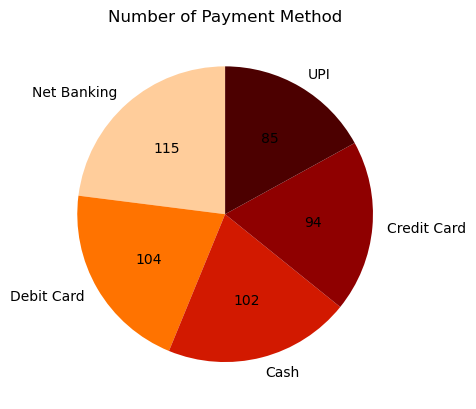

In [35]:
# Count of each payment method
ax = df["PaymentMethod"].value_counts()

# Generate color palette using gist_heat_r
color = plt.get_cmap("gist_heat_r")(
    np.linspace(0.1,0.8,len(ax))
)

# Pie chart using Matplotlib
plt.pie(
    ax, 
    labels = ax.index , 
    autopct = lambda p: int(round(p*sum(ax)/100)), 
    colors = color, 
    startangle = 90
)

# Title
plt.title("Number of Payment Method")

# Display Chart
plt.show()

From the above Pie Chart, we can observe that net Banking is the most frequently used payment method, indicating strong customer preference for online banking transactions. Debit Card and Cash also show high usage, suggesting customers prefer straightforward and familiar payment options. UPI has the lowest count, indicating it is used but not as widely adopted compared to other methods.

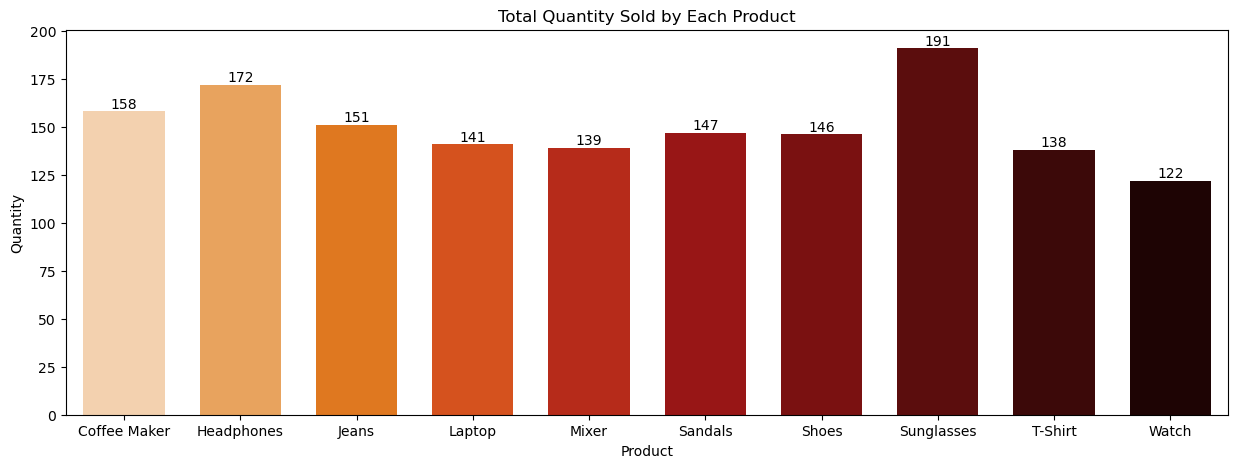

In [38]:
# Total quantity sold per product
total = (
    df.groupby("Product")["Quantity"]
    .sum()
    .reset_index()
)

# Bar chart using Seaborn
plt.figure(figsize=(15,5))
ax = sns.barplot(
    x = "Product", 
    y = "Quantity", 
    data = total, 
    hue = "Product", 
    palette = "gist_heat_r", 
    width = 0.7
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container)

# Title
plt.title("Total Quantity Sold by Each Product")

# Display Chart
plt.show()

From the above chart, we can observe that sunglasses recorded the highest quantity sold, indicating very strong customer preference and high turnover. Headphones also performed exceptionally well, ranking second in total units sold and showing consistent demand. Products like Watches and T-Shirts sold comparatively fewer units, suggesting they may require stronger promotion

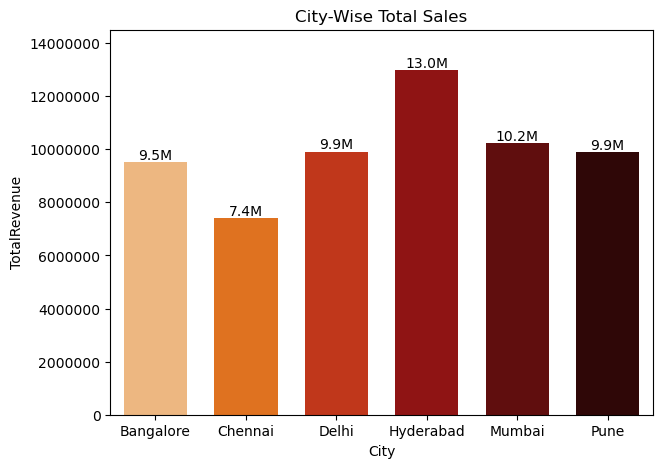

In [40]:
# City-wise Total Revenue Bar Chart
plt.figure(figsize = (7,5))
plt.ticklabel_format(style = "plain")

# Grouping Total Revenue by City
city_revenue = (
    df.groupby("City")["TotalRevenue"]
    .sum()
    .reset_index()
)

# Bar chart using Seaborn
ax = sns.barplot(
    x = "City", 
    y = "TotalRevenue", 
    data = city_revenue, 
    hue = "City", 
    palette = "gist_heat_r", 
    width = 0.7
)

# Adding labels on each bar
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v/1000000:.1f}M" for v in container.datavalues])

# Chart Title & Y-axis Limit
plt.title("City-Wise Total Sales")
plt.ylim(0,14500000)

# Display Chart
plt.show()

From the above graph, we observe that Hyderabad generates the highest revenue among all cities at ₹1.29 Cr, making it the strongest performing market whereas Chennai has the lowest sales, indicating potential scope for improvement or targeted marketing.

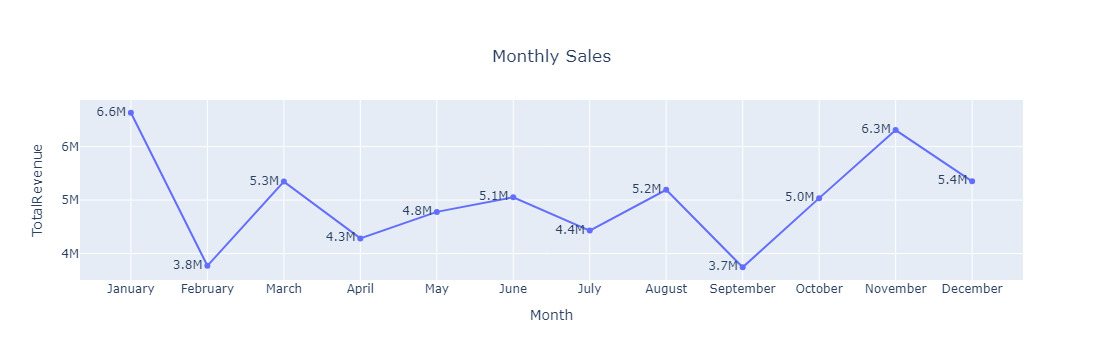

In [57]:
# Calculate monthly total revenue
monthly = (
    df.groupby("Month")["TotalRevenue"]
    .sum()
    .reset_index()
)

# Define correct chronological month order
Month_Order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

# Convert Month column to ordered categorical and sort
monthly["Month"] = pd.Categorical(
    monthly["Month"], 
    categories = Month_Order, 
    ordered = True
)
monthly = monthly.sort_values("Month")

monthly["label"] = monthly["TotalRevenue"].apply(lambda x: f"{x/1000000:.1f}M")

# Line chart using Plotly
fig = px.line(
    monthly, 
    x = "Month", 
    y = "TotalRevenue", 
    title = "Monthly Sales",
    text = "label"
)

fig.update_traces(textposition = "middle left")
fig.update_layout(title = {"x": 0.5, "xanchor": "center", "yanchor": "top"})

# Display Chart
fig.show()

From the above graph, we observe that Monthly sales show strong peaks in January and November, while February and September mark the lowest revenue periods. Overall, the trend reflects seasonal fluctuations with a strong year-end recovery.

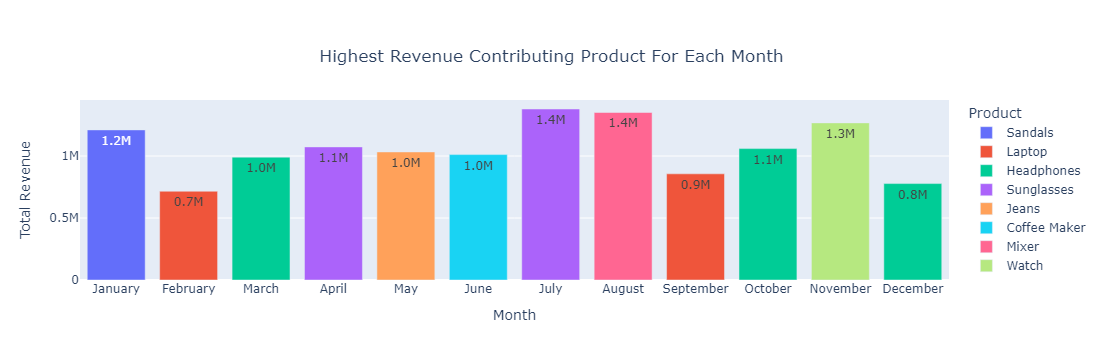

In [46]:
# Calculate Monthly Reevnue of Each Product
monthly_product = (
    df.groupby(["Month","Product"])["TotalRevenue"]
    .sum()
    .reset_index()
)

# Conevrt Monthly Column to Ordered Categorical and Sort
monthly_product["Month"] = pd.Categorical(
    monthly_product["Month"], 
    categories = Month_Order, 
    ordered = True
)

monthly_product = monthly_product.sort_values("Month")

# Get Top Product for Each Month
top_product = (
    monthly_product
    .sort_values(
        ["Month","TotalRevenue"], 
        ascending = [True, False]
    )
    .drop_duplicates(
        subset = "Month", 
        keep = "first"
    )
)

# Bar Chart Using Plotly
fig = px.bar(
    top_product, 
    x = "Month", 
    y = "TotalRevenue", 
    color = "Product", 
    title = "Highest Revenue Contributing Product For Each Month", 
    text = top_product["TotalRevenue"].apply(lambda x: f"{x/1000000:.1f}M"), 
    category_orders = {"Month": Month_Order},
)

# Layout
fig.update_layout(
    title = {
        "x": 0.5, 
        "xanchor" : "center", 
        "yanchor" : "top"
    },
    xaxis_title = "Month", 
    yaxis_title = "Total Revenue"
)

# Display Chart
fig.show()             

From the above graph, we observe that among all products, Headphones appear most frequently as the highest revenue-contributing product, indicating consistently strong consumer demand and a major share in monthly revenue contribution.

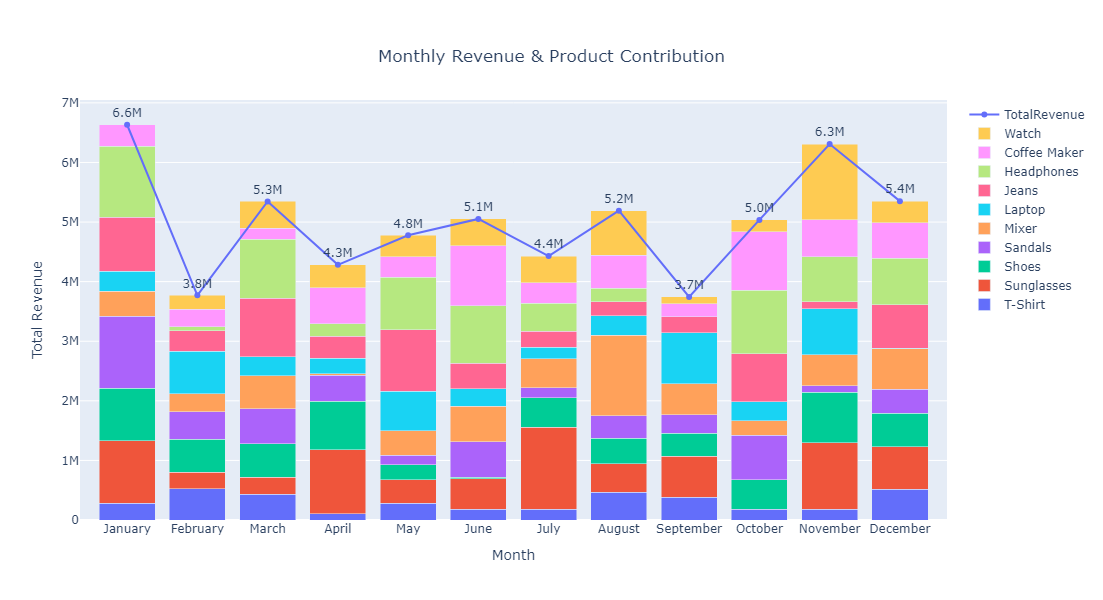

In [48]:
fig = go.Figure()

# Bar Traces for Each Product
for product in monthly_product["Product"].unique():
    product_data = monthly_product[monthly_product["Product"] == product]

    fig.add_trace(
        go.Bar(
            x = product_data["Month"], 
            y = product_data["TotalRevenue"], 
            name = product
        )
    )

# Total Revenue Line
fig.add_trace(
    go.Scatter(
        x = monthly["Month"], 
        y = monthly["TotalRevenue"], 
        mode = "lines+markers+text", 
        name = "TotalRevenue", 
        text = [f"{x/1000000:.1f}M" for x in monthly["TotalRevenue"]], 
        textposition = "top center")
)

# Layout
fig.update_layout(
    barmode = "stack", 
    title = {
        "text" : "Monthly Revenue & Product Contribution", 
        "x" : 0.5, 
        "xanchor" : "center", 
        "yanchor": "top"
    }, 
    xaxis_title = "Month", 
    yaxis_title = "Total Revenue", 
    height = 600
)

# Display Chart
fig.show()

From the above graph, we observe that the revenue remains stable through the year, with major peaks in January and November driven by high seasonal demand. Headphones contribute consistently across months, emerging as the strongest performing product category. Sunglasses and Watches also show noticeable seasonal spikes, adding to overall revenue growth.

# Conculsion

This analysis highlights clear sales patterns across products, cities, and time periods. Headphones and Sunglasses consistently stand out as the highest revenue-generating products, indicating strong and stable demand. City-wise performance also reveals a set of high-impact locations that drive a significant portion of overall revenue. Monthly sales trends show noticeable fluctuations, offering valuable direction for forecasting and seasonal planning.

# Recommendations

> Focus on high-performing products by aligning marketing campaigns and inventory levels with demand.

> Strengthen presence in top-performing cities to leverage existing market potential.

> Support underperforming products through promotions, revised pricing, or improved visibility.

> Utilize monthly trend patterns to optimize planning, budgeting, and campaign scheduling.